In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Food_Delivery.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


handle missing values

In [ ]:
cols = ['Weather',	'Traffic_Level'	,'Time_of_Day']
df[cols]= df[cols].fillna(df[cols].mode().iloc[0])

In [ ]:
df['Courier_Experience_yrs']  =df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [ ]:
df = df.drop('Order_ID',axis=1)

column vs target by boxplot

In [ ]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


#distribution of Target use histplot


<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

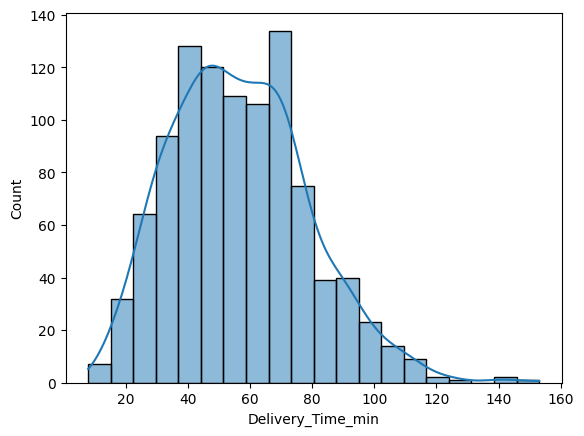

In [ ]:
sns.histplot(df['Delivery_Time_min'] , kde=True , bins=20)

Corr of numeric col use heatmap

<Axes: >

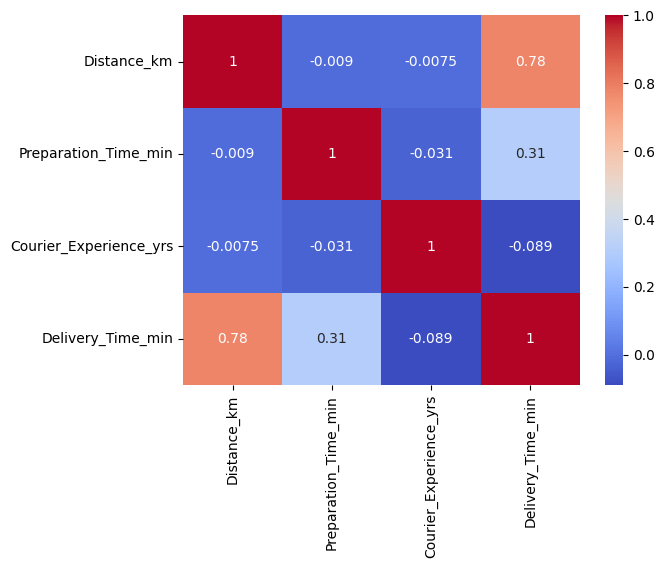

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True,  cmap='coolwarm')

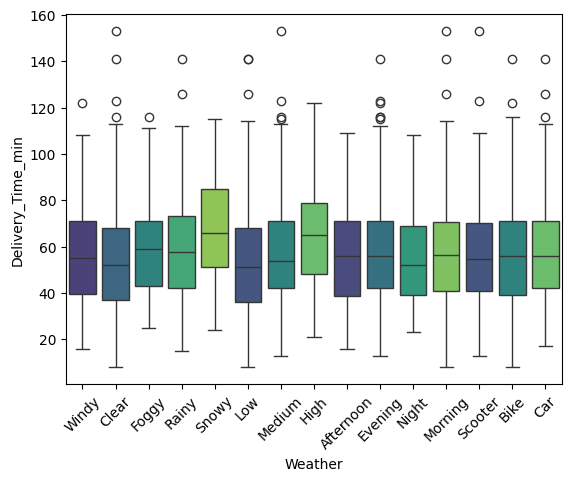

In [ ]:
#For category and Target Use boxplot
cols = ['Weather',	'Traffic_Level'	,'Time_of_Day' , 'Vehicle_Type']
for col in cols:
  sns.boxplot(x=col, y='Delivery_Time_min' , data=df , palette='viridis')
  plt.xticks(rotation =45)

In [ ]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [ ]:
#perform anova for target vs cat_cols
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

from scipy.stats import f_oneway

anova_results = {}

for col in cat_cols:
#"Har category ka Delivery_Time_min ka data nikalo aur ek list mein store karo."
    groups = [
        group['Delivery_Time_min'].values
        for name, group in df.groupby(col)
    ]

    f_stats, p_value = f_oneway(*groups)

    anova_results[col] = {
        'f_statistics': f_stats,
        'p_value': p_value
    }

anova_df = pd.DataFrame(anova_results).T

anova_df['significance (p<0.05)'] = anova_df['p_value'] < 0.05

anova_df = anova_df.sort_values(
    by='f_statistics',
    ascending=False
)

print(anova_df)


               f_statistics       p_value  significance (p<0.05)
Traffic_Level     19.751338  3.869707e-09                   True
Weather           10.499059  2.472288e-08                   True
Vehicle_Type       0.589374  5.548673e-01                  False
Time_of_Day        0.346766  7.915077e-01                  False


In [ ]:
#label encoder to apply RF
from sklearn.preprocessing import LabelEncoder
le  = LabelEncoder()
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_cols:
  df[col] = le.fit_transform(df[col])
df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


In [ ]:
#evaluate
X = df.drop(['Delivery_Time_min','Time_of_Day', 'Vehicle_Type'] , axis=1)
y = df['Delivery_Time_min']

In [ ]:
#train the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
#predict the model
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

In [ ]:
#check r2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.46716884436499373

In [ ]:
#Apply RandomForest for increase accuracy
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
r2 = r2_score(y_test,y_pred)
r2

0.7821783264180515

In [ ]:
#apply hyperparamter tuning to increase accuracy again
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None,5,10,15,20],
    'max_features' : ['sqrt','log2',1.0],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

#create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state = 42),
    param_distributions = param_grid,
    n_iter=20,
    scoring='r2',
    n_jobs=-1,
    cv = 5
)

#fit and predict the model
random_search.fit(X_train,y_train)
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
r2 = r2_score(y_test,y_pred)
print("r2",r2)

#check which para grid is best and estimator
print(random_search.best_params_)

r2 0.785308746096973
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}


In [ ]:
import pickle

# best model obtained from RandomizedSearchCV
best_rf = random_search.best_estimator_

# save model
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)

print("Random Forest model saved!")

Random Forest model saved!


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pickle

cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# save all encoders together
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(encoders, file)

print("Label encoders saved!")

Label encoders saved!


In [ ]:
import os

print(os.listdir())

['.config', 'Food_Delivery.csv', 'random_forest_model.pkl', 'label_encoders.pkl', 'sample_data']
